# Task
Implement and train a Multilayer Perceptron model for MNIST handwritten digit classification using TensorFlow Keras, then evaluate its performance.

## Load data

### Subtask:
Load the MNIST dataset from TensorFlow Keras.


**Reasoning**:
Import the MNIST dataset and load it into training and testing sets.



In [1]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Preprocess data

### Subtask:
Normalize the image data and one-hot encode the labels.


**Reasoning**:
Reshape, cast, and normalize the image data, and one-hot encode the labels.



In [2]:
import numpy as np
from tensorflow.keras.utils import to_categorical

x_train = x_train.reshape(x_train.shape[0], 28 * 28).astype('float32') / 255.0
x_test = x_test.reshape(x_test.shape[0], 28 * 28).astype('float32') / 255.0

y_train_one_hot = to_categorical(y_train, num_classes=10)
y_test_one_hot = to_categorical(y_test, num_classes=10)

## Build model

### Subtask:
Construct a Multilayer Perceptron model using Keras.


**Reasoning**:
Construct the Multilayer Perceptron model using Keras Sequential API as per the instructions.



In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(units=128, activation='relu', input_shape=(784,)))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compile model

### Subtask:
Compile the model by specifying the optimizer, loss function, and metrics.


**Reasoning**:
Compile the Keras model with the specified optimizer, loss function, and metrics.



In [4]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Train model

### Subtask:
Train the model on the training data and evaluate it on the test data.


**Reasoning**:
Train the model on the training data and evaluate it on the test data as requested by the instructions.



In [6]:
history = model.fit(x_train, y_train_one_hot, epochs=10, batch_size=32)
evaluation_results = model.evaluate(x_test, y_test_one_hot)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9959 - loss: 0.0119
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9953 - loss: 0.0138
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9958 - loss: 0.0121
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9972 - loss: 0.0086
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9956 - loss: 0.0139
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9973 - loss: 0.0089
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9971 - loss: 0.0088
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9961 - loss: 0.0102
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9963 - loss: 0.0100
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9965 - loss: 0.0103
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9783 - loss: 0.1404


## Evaluate Model

### Subtask:
Display the model's performance metrics.

**Reasoning**:
Display the evaluation results to assess the model's performance on the test data.

In [7]:
print(f"Test Loss: {evaluation_results[0]}")
print(f"Test Accuracy: {evaluation_results[1]}")

Test Loss: 0.11422249674797058
Test Accuracy: 0.980400025844574


## Finish task

Summarize the results and provide insights into the model's performance.

## Test with a single image

### Subtask:
Select an image, predict its class, and check if the prediction is correct.

**Reasoning**:
Select a sample image from the test set, make a prediction using the trained model, and compare the predicted class with the actual class to determine correctness.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


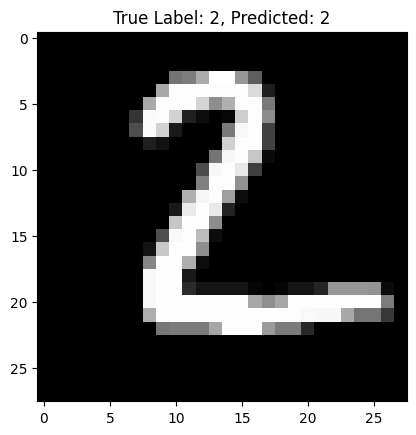

Prediction is correct!


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Select an image from the test set (e.g., the first image)
image_index = 1
test_image = x_test[image_index].reshape(1, 784)
true_label = y_test[image_index]

# Make a prediction
prediction = model.predict(test_image)
predicted_class = np.argmax(prediction)

# Display the image and the prediction
plt.imshow(x_test[image_index].reshape(28, 28), cmap='gray')
plt.title(f"True Label: {true_label}, Predicted: {predicted_class}")
plt.show()

# Check if the prediction is correct
if predicted_class == true_label:
    print("Prediction is correct!")
else:
    print("Prediction is incorrect.")